# **Détection des dattes fruits avec YOLOv8**

In [2]:
import os
import shutil
import zipfile
from pathlib import Path

* ***Préparer Data pour entrainement avec Yolov8*** : (labels + images)

* Préparer les labels :

In [3]:

ANNOTATION_ZIP_PATH = "/content/drive/MyDrive/Projet_fil_rouge/Annotations.zip"
ANNOTATION_EXTRACT_DIR = "/content/dataset_raw_annotation"

os.makedirs(ANNOTATION_EXTRACT_DIR, exist_ok=True)

print("📦 Décompression du fichier...")

with zipfile.ZipFile(ANNOTATION_ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(ANNOTATION_EXTRACT_DIR)

print("✅ Extraction terminée dans :", ANNOTATION_EXTRACT_DIR)

# afficher le contenu extrait
print("\n📂 Contenu extrait :")
for root, dirs, files in os.walk(ANNOTATION_EXTRACT_DIR):
    print(root, "→", len(files), "fichiers")

📦 Décompression du fichier...
✅ Extraction terminée dans : /content/dataset_raw_annotation

📂 Contenu extrait :
/content/dataset_raw_annotation → 0 fichiers
/content/dataset_raw_annotation/Annotations → 0 fichiers
/content/dataset_raw_annotation/Annotations/classification → 4 fichiers
/content/dataset_raw_annotation/Annotations/object detection → 0 fichiers
/content/dataset_raw_annotation/Annotations/object detection/date fruits detection → 9029 fichiers
/content/dataset_raw_annotation/Annotations/object detection/date fruits maturity → 9029 fichiers
/content/dataset_raw_annotation/Annotations/object detection/date fruits varieties → 9029 fichiers


1️⃣ créer le dossier destination

2️⃣ copier les annotations de détection

3️⃣ supprimer le dossier dataset_raw_annotation

In [4]:

# chemins
SOURCE_DIR = "/content/dataset_raw_annotation/Annotations/object detection/date fruits detection"
TARGET_DIR = "/content/dataset_detection/labels"
RAW_DIR = "/content/dataset_raw_annotation"

# créer dossier destination
os.makedirs(TARGET_DIR, exist_ok=True)

print("📂 Copie des annotations...")

# copier tous les fichiers
for file in os.listdir(SOURCE_DIR):

    src_file = os.path.join(SOURCE_DIR, file)
    dst_file = os.path.join(TARGET_DIR, file)

    if os.path.isfile(src_file):
        shutil.copy(src_file, dst_file)

print("✅ Annotations copiées dans :", TARGET_DIR)

# supprimer le dossier raw
print("🗑️ Suppression du dossier dataset_raw_annotation...")
shutil.rmtree(RAW_DIR)

print("🎉 Nettoyage terminé")

📂 Copie des annotations...
✅ Annotations copiées dans : /content/dataset_detection/labels
🗑️ Suppression du dossier dataset_raw_annotation...
🎉 Nettoyage terminé


* Vérifier les fichiers copiés

In [5]:
print("Nombre d'annotations :", len(os.listdir("/content/dataset_detection/labels")))

Nombre d'annotations : 9029


* préparer les images :

In [6]:

SOURCE_DIR = "/content/drive/MyDrive/Projet_fil_rouge/dataset_variete/PFE_Dataset_Classification"
TARGET_DIR = "/content/dataset_detection/images"

IMAGE_EXT = [".jpg", ".jpeg", ".png"]

os.makedirs(TARGET_DIR, exist_ok=True)

img_count = 0

print("📦 Fusion des images...")

# parcourir tous les sous dossiers
for root, dirs, files in os.walk(SOURCE_DIR):

    for file in files:

        if Path(file).suffix.lower() in IMAGE_EXT:

            src_path = os.path.join(root, file)
            dst_path = os.path.join(TARGET_DIR, file)

            # vérifier si image existe déjà
            if not os.path.exists(dst_path):

                shutil.copy(src_path, dst_path)
                img_count += 1
                if img_count%10 == 0 :
                  print(f"    🔔{img_count} images ...")

            else:
                print(f"⚠️ Image déjà existante ignorée : {file}")

print(f"\n✅ {img_count} images copiées dans {TARGET_DIR}")

📦 Fusion des images...
    🔔10 images ...
    🔔20 images ...
    🔔30 images ...
    🔔40 images ...
    🔔50 images ...
    🔔60 images ...
    🔔70 images ...
    🔔80 images ...
    🔔90 images ...
    🔔100 images ...
    🔔110 images ...
    🔔120 images ...
    🔔130 images ...
    🔔140 images ...
    🔔150 images ...
    🔔160 images ...
    🔔170 images ...
    🔔180 images ...
    🔔190 images ...
    🔔200 images ...
    🔔210 images ...
    🔔220 images ...
    🔔230 images ...
    🔔240 images ...
    🔔250 images ...
    🔔260 images ...
    🔔270 images ...
    🔔280 images ...
    🔔290 images ...
    🔔300 images ...
    🔔310 images ...
    🔔320 images ...
    🔔330 images ...
    🔔340 images ...
    🔔350 images ...
    🔔360 images ...
    🔔370 images ...
    🔔380 images ...
    🔔390 images ...
    🔔400 images ...
    🔔410 images ...
    🔔420 images ...
    🔔430 images ...
    🔔440 images ...
    🔔450 images ...
    🔔460 images ...
    🔔470 images ...
    🔔480 images ...
    🔔490 images ...
    🔔5

In [7]:
print("Images :", len(os.listdir("/content/dataset_detection/images")))
print("Labels :", len(os.listdir("/content/dataset_detection/labels")))

Images : 9091
Labels : 9029


*  vérifie chaque image

*  affiche celles qui n'ont pas de label

*  les supprime





In [8]:
import os
import cv2
import matplotlib.pyplot as plt

IMAGES_DIR = "/content/dataset_detection/images"
LABELS_DIR = "/content/dataset_detection/labels"

IMAGE_EXT = [".jpg", ".jpeg", ".png"]

missing_images = []

# vérifier les labels
for img in os.listdir(IMAGES_DIR):

    if os.path.splitext(img)[1].lower() in IMAGE_EXT:

        name = os.path.splitext(img)[0]
        label_path = os.path.join(LABELS_DIR, name + ".txt")

        if not os.path.exists(label_path):
            missing_images.append(img)

print("Images sans label :", len(missing_images))


# afficher les images
for img in missing_images:

    img_path = os.path.join(IMAGES_DIR, img)

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4,4))
    plt.imshow(image)
    plt.title(f"Sans label : {img}")
    plt.axis("off")
    plt.show()


# supprimer les images
for img in missing_images:

    os.remove(os.path.join(IMAGES_DIR, img))

print(f"🗑️ {len(missing_images)} images supprimées")

Output hidden; open in https://colab.research.google.com to view.

In [9]:
print("Images :", len(os.listdir("/content/dataset_detection/images")))
print("Labels :", len(os.listdir("/content/dataset_detection/labels")))

Images : 9010
Labels : 9029


***

* Afficher une échantillon des images :

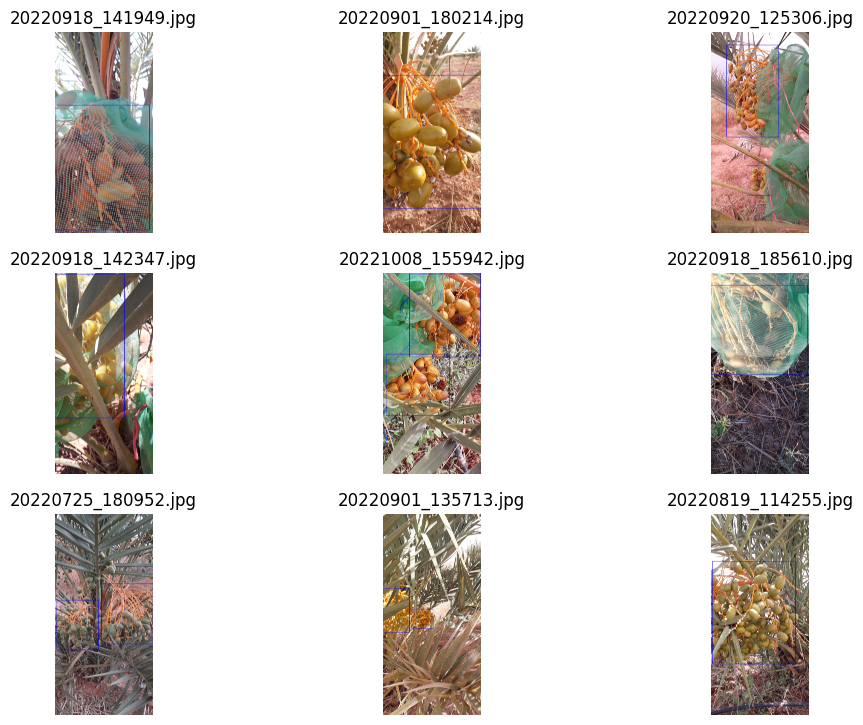

In [19]:
import os
import cv2
import random
import matplotlib.pyplot as plt


IMAGES_DIR = "/content/dataset_detection/images"
LABELS_DIR = "/content/dataset_detection/labels"


# -----------------------------
# lire les annotations YOLO
# -----------------------------
def read_yolo_label(label_path):

    boxes = []

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        cls, xc, yc, w, h = map(float, line.split())
        boxes.append((cls, xc, yc, w, h))

    return boxes


# -----------------------------
# dessiner bounding boxes
# -----------------------------
def draw_boxes(image, boxes):

    h, w, _ = image.shape

    for cls, xc, yc, bw, bh in boxes:

        x_center = xc * w
        y_center = yc * h

        box_w = bw * w
        box_h = bh * h

        x_min = int(x_center - box_w / 2)
        y_min = int(y_center - box_h / 2)

        x_max = int(x_center + box_w / 2)
        y_max = int(y_center + box_h / 2)

        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0,0,255), 6)

    return image


# -----------------------------
# afficher échantillons
# -----------------------------
def show_random_samples(n_samples=9):

    images = os.listdir(IMAGES_DIR)
    samples = random.sample(images, n_samples)

    cols = 3
    rows = (n_samples // cols) + 1

    plt.figure(figsize=(12,12))

    for i, img_name in enumerate(samples):

        img_path = os.path.join(IMAGES_DIR, img_name)
        label_path = os.path.join(LABELS_DIR, os.path.splitext(img_name)[0] + ".txt")

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if os.path.exists(label_path):
            boxes = read_yolo_label(label_path)
            img = draw_boxes(img, boxes)

        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.title(img_name)
        plt.axis("off")

    plt.show()


# -----------------------------
# exécuter
# -----------------------------
show_random_samples(9)

## Split Data to Train, Test, Val (70%, 20%, 10%)

1️⃣ mélanger les images
2️⃣ faire le split 70 / 20 / 10
3️⃣ déplacer image + label correspondant ensemble
4️⃣ créer la structure correcte.

In [32]:
import os
import random
import shutil

BASE_DIR = "/content/dataset_detection"

IMAGES_DIR = os.path.join(BASE_DIR, "images")
LABELS_DIR = os.path.join(BASE_DIR, "labels")

TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1

# créer dossiers
splits = ["train", "val", "test"]

for split in splits:
    os.makedirs(os.path.join(BASE_DIR, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(BASE_DIR, split, "labels"), exist_ok=True)


# récupérer images
images = [f for f in os.listdir(IMAGES_DIR) if f.endswith((".jpg",".png",".jpeg", ".JPG",".PNG",".JPEG"))]

random.shuffle(images)

n_total = len(images)
n_train = int(n_total * TRAIN_RATIO)
n_val = int(n_total * VAL_RATIO)

train_images = images[:n_train]
val_images = images[n_train:n_train+n_val]
test_images = images[n_train+n_val:]


def move_files(image_list, split):

    for img in image_list:

        name = os.path.splitext(img)[0]

        img_src = os.path.join(IMAGES_DIR, img)
        lbl_src = os.path.join(LABELS_DIR, name + ".txt")

        img_dst = os.path.join(BASE_DIR, split, "images", img)
        lbl_dst = os.path.join(BASE_DIR, split, "labels", name + ".txt")

        shutil.move(img_src, img_dst)

        if os.path.exists(lbl_src):
            shutil.move(lbl_src, lbl_dst)


# déplacer fichiers
move_files(train_images, "train")
move_files(val_images, "val")
move_files(test_images, "test")


print("Dataset split terminé")
print("Train :", len(train_images))
print("Val :", len(val_images))
print("Test :", len(test_images))

Dataset split terminé
Train : 510
Val : 145
Test : 74


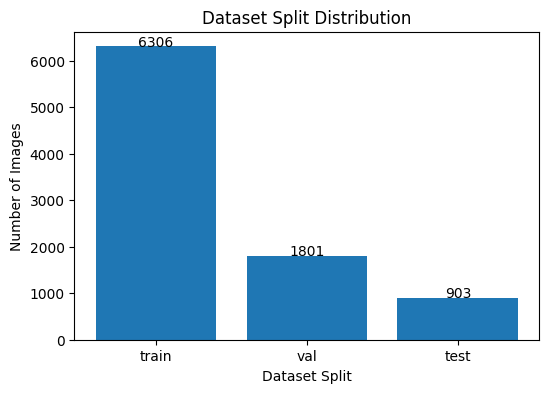

In [33]:
import os
import matplotlib.pyplot as plt

BASE_DIR = "/content/dataset_detection"

def count_images():

    train_count = len(os.listdir(os.path.join(BASE_DIR, "train/images")))
    val_count = len(os.listdir(os.path.join(BASE_DIR, "val/images")))
    test_count = len(os.listdir(os.path.join(BASE_DIR, "test/images")))

    return {
        "train": train_count,
        "val": val_count,
        "test": test_count
    }


def plot_distribution(data):

    labels = list(data.keys())
    values = list(data.values())

    plt.figure(figsize=(6,4))
    plt.bar(labels, values)

    plt.title("Dataset Split Distribution")
    plt.xlabel("Dataset Split")
    plt.ylabel("Number of Images")

    for i,v in enumerate(values):
        plt.text(i, v+5, str(v), ha='center')

    plt.show()


data = count_images()
plot_distribution(data)

In [37]:
print("Images :", len(os.listdir("/content/dataset_detection/images")))
print("Labels :", len(os.listdir("/content/dataset_detection/labels")))
print(f"==="*20)
print("Images - Train :", len(os.listdir("/content/dataset_detection/train/images")))
print("Labels - Train :", len(os.listdir("/content/dataset_detection/train/labels")))
print(f"==="*20)
print("Images - Val :", len(os.listdir("/content/dataset_detection/val/images")))
print("Labels - Val :", len(os.listdir("/content/dataset_detection/val/labels")))
print(f"==="*20)
print("Images - Test :", len(os.listdir("/content/dataset_detection/test/images")))
print("Labels - Test :", len(os.listdir("/content/dataset_detection/test/labels")))

Images : 0
Labels : 19
Images - Train : 6306
Labels - Train : 6306
Images - Val : 1801
Labels - Val : 1801
Images - Test : 903
Labels - Test : 903


In [38]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.3 MB/s eta 0:00:00


In [39]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/dataset_detection/data.yaml",
    imgsz=640,
    epochs=1,
    batch=16
)

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
train: /content/dataset_detection/train/images/20220919_190128.jpg: corrupt JPEG restored and saved
train: /content/dataset_detection/train/images/20220919_190129(0).jpg: corrupt JPEG restored and saved
train: /content/dataset_detection/train/images/20220919_190129.jpg: corrupt JPEG restored and saved
train: /content/dataset_detection/train/images/20220919_190130.jpg: corrupt JPEG restored and saved
train: /content/dataset_detection/train/images/20220919_190131.jpg: corrupt JPEG restored and saved
train: /content/dataset_detection/train/images/20220919_190132(0).jpg: corrupt JPEG restored and saved
train: /content/dataset_detection/train/images/20220919_190132.jpg: corrupt JPEG restored and saved
train: /content/dataset_detection/train/images/20220919_190139.jpg: corrupt JPEG restored and saved
train: /content/dataset_detection/train/images/20220919_190140.jpg: corrupt JPEG restored and saved
train: /content/

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d863992a8a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [43]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

metrics = model.val(
    data="/content/dataset_detection/data.yaml",
    split="test",
    imgsz=640,
    batch=9,
    device="cpu",
    verbose=False
)

print("mAP50-95 :", metrics.box.map)
print("mAP50    :", metrics.box.map50)
print("Precision:", metrics.box.p)
print("Recall   :", metrics.box.r)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 139.5±26.0 MB/s, size: 4432.1 KB)
val: Scanning /content/dataset_detection/test/labels... 903 images, 0 backgrounds, 3 corrupt: 100% ━━━━━━━━━━━━ 903/903 3.7it/s 4:07
val: /content/dataset_detection/test/images/20220725_181051.jpg: corrupt JPEG restored and saved
val: /content/dataset_detection/test/images/20220725_181054.jpg: corrupt JPEG restored and saved
val: /content/dataset_detection/test/images/20220725_181133.jpg: corrupt JPEG restored and saved
val: /content/dataset_detection/test/images/20220725_181519.jpg: corrupt JPEG restored and saved
val: /content/dataset_detection/test/images/20220725_181609.jpg: corrupt JPEG restored and saved
val: /content/dataset_detection/test/images/20220725_181631.jpg: corrupt JPEG restored and saved
val: /content/dataset_detection/test/

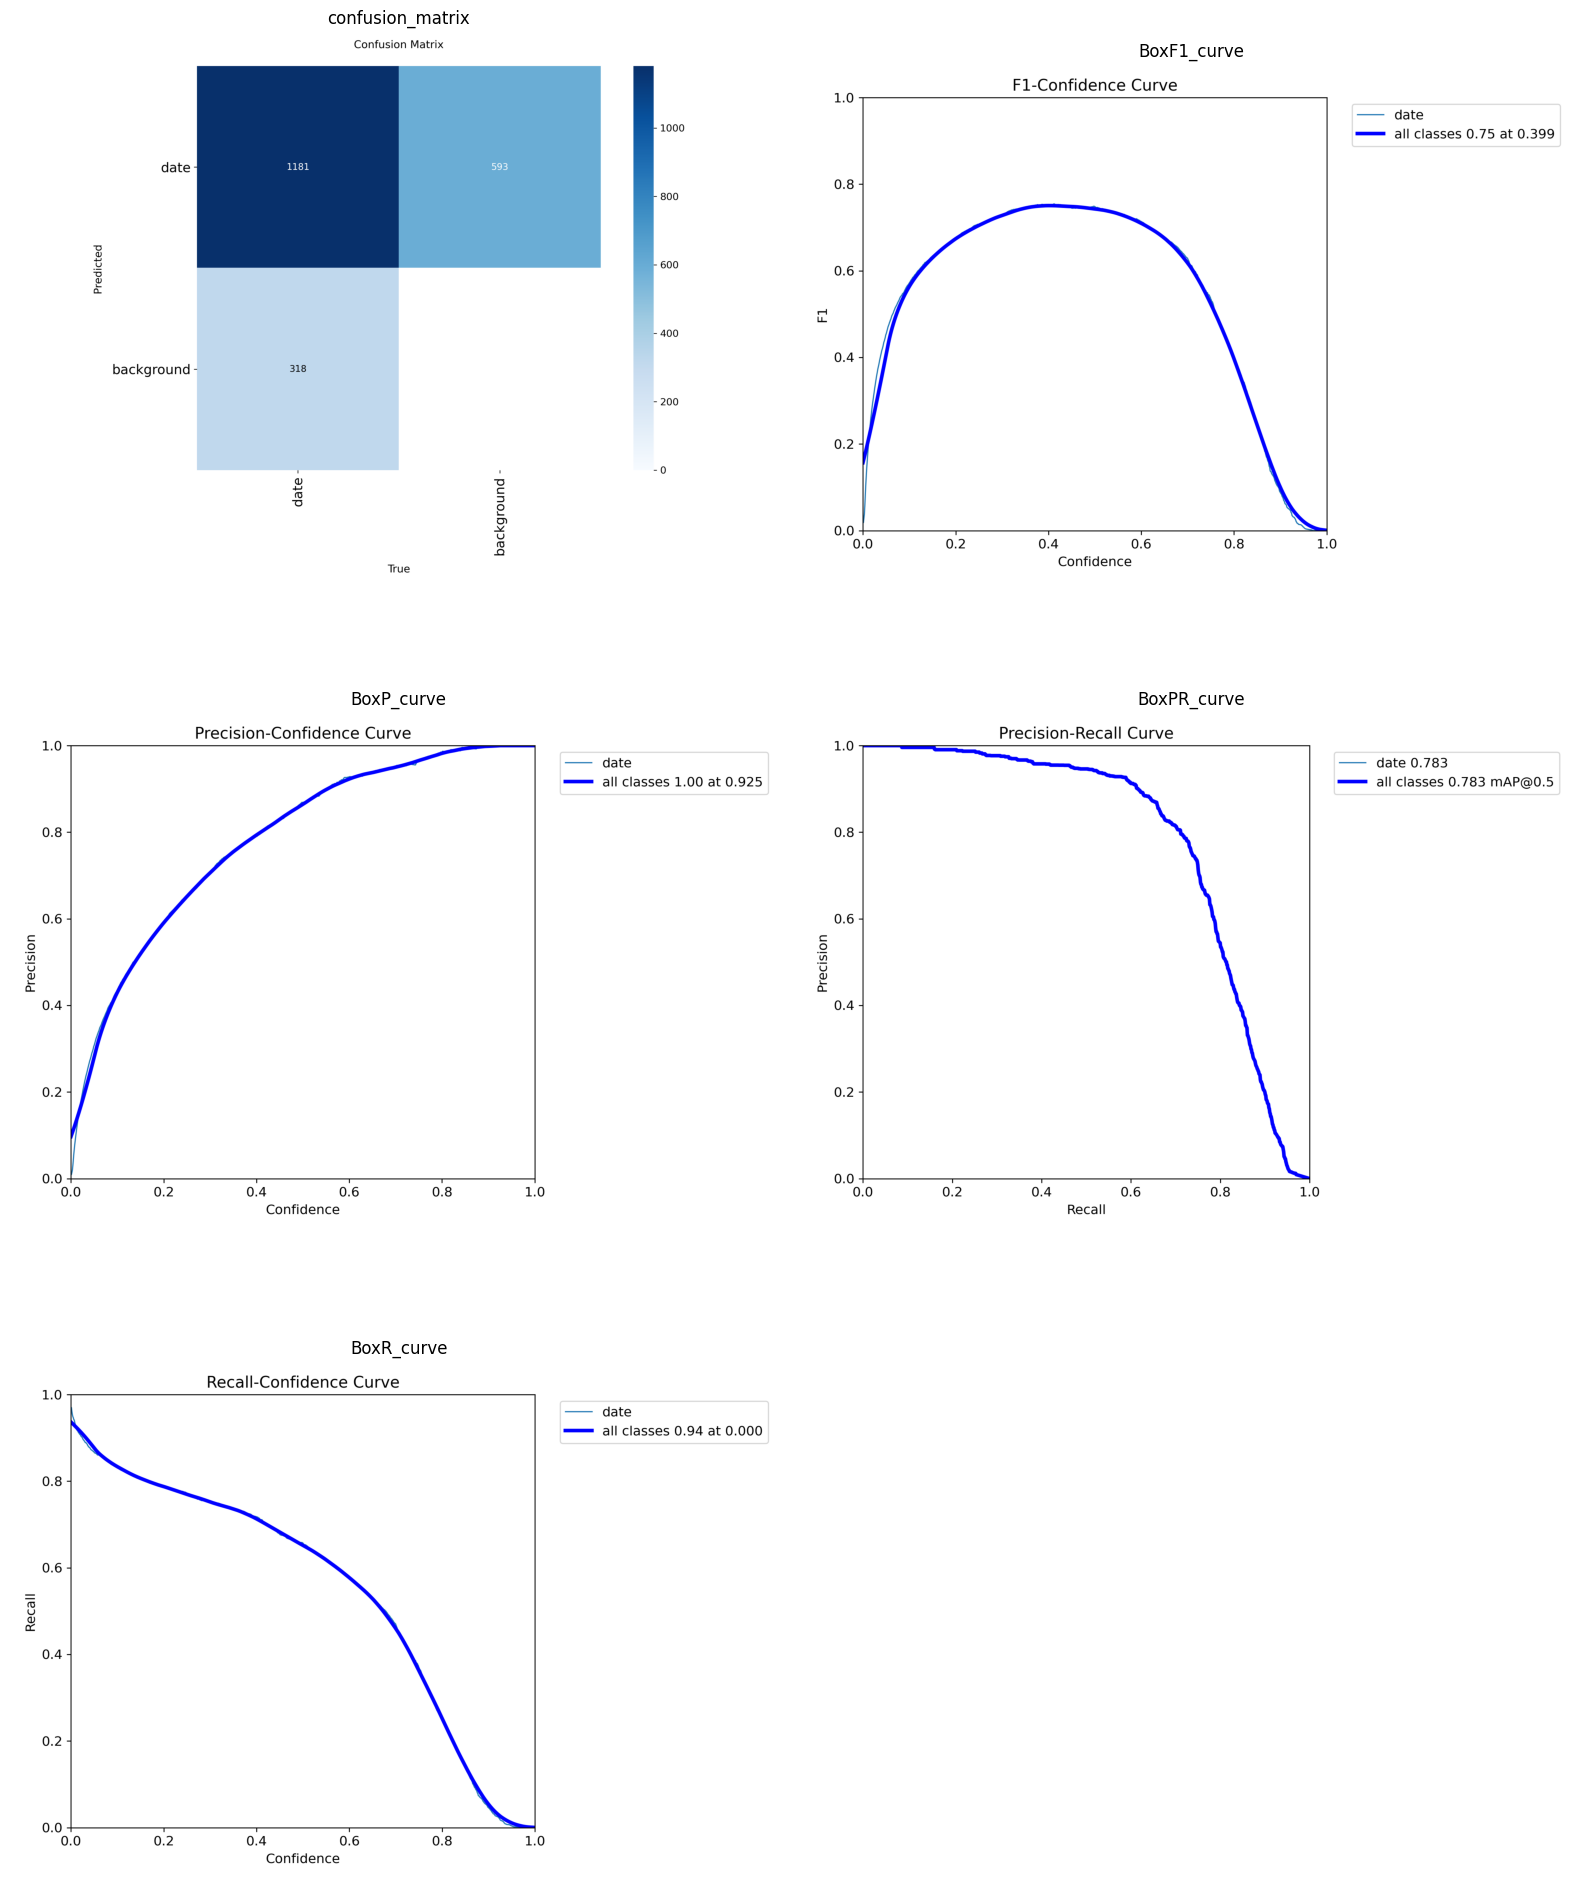

In [55]:
import cv2
import matplotlib.pyplot as plt
import os

RESULTS_DIR = "./runs/detect/val4"

images = [
    "confusion_matrix",
    'BoxF1_curve',
    'BoxP_curve',
    'BoxPR_curve',
    'BoxR_curve'
]

def show_evaluation_plots():

    plt.figure(figsize=(16,20))

    for i, img_name in enumerate(images):

        path = os.path.join(RESULTS_DIR, img_name + ".png")

        if os.path.exists(path):

            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(3,2,i+1)
            plt.imshow(img)
            plt.title(img_name)
            plt.axis("off")

    plt.tight_layout()
    plt.show()


show_evaluation_plots()


image 1/1 /content/dataset_detection/test/images/20220901_180242.jpg: 640x320 3 dates, 386.1ms
Speed: 8.0ms preprocess, 386.1ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 320)


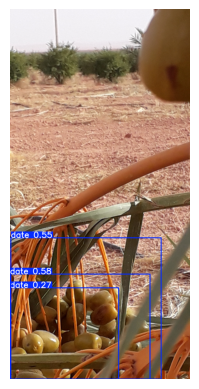

In [49]:
import os
import random
import cv2

image_path = '/content/dataset_detection/test/images/'

images_list = os.listdir(image_path)

random_number = (random.randint(1, len(images_list)))

pred_1 = model.predict(source=image_path + images_list[random_number], conf=0.25)

annotated_img = pred_1[0].plot()

annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.imshow(annotated_img)
plt.axis("off")
plt.show()

In [53]:
model.save("/content/drive/MyDrive/Projet_fil_rouge/models/date_detector_model.pt")